# Lapiz Blue ML Models — Forecasting + Anomaly Detection

**Student task:** Build two ML parts:

1. **Forecasting model** using `person4_forecasting_dataset.csv`  
   - Target: `next_month_ebitda_aed`  
   - Models: Linear Regression, Random Forest Regressor  
   - Metrics: MAE, RMSE, R²  
   - Output: Actual vs Predicted EBITDA chart

2. **Anomaly detection model** using `person5_anomaly_detection_dataset.csv`  
   - Evaluation label: `is_anomaly_label`  
   - Model: Isolation Forest  
   - Metrics: confusion matrix, precision, recall, F1-score  
   - Output: anomaly alerts table with plain-English explanations


## 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


---
# Part A — EBITDA Forecasting

The forecasting task predicts **next month EBITDA** using current-month financial and operational features.


## 2. Load forecasting dataset

In [2]:
forecast_path = 'person4_forecasting_dataset.csv'
df_forecast = pd.read_csv(forecast_path)

print('Shape:', df_forecast.shape)
display(df_forecast.head())


Shape: (102, 38)


,period,company_id,company_name,sector,next_month_ebitda_aed,revenue_aed,budget_revenue_aed,cost_of_sales_aed,operating_expenses_aed,gross_profit_aed,ebitda_aed,budget_ebitda_aed,cash_in_aed,cash_out_aed,overdue_receivables_aed,headcount,customer_count,leads_or_orders,conversion_rate_pct,on_time_delivery_pct,customer_satisfaction_score,complaints_count,open_tasks_count,avg_resolution_days,employee_utilization_pct,data_quality_score_pct,profit_margin,gross_margin,expense_ratio,overdue_receivable_ratio,budget_variance_percentage,cash_flow_net_aed,cash_flow_margin,revenue_growth,expense_growth,ebitda_growth,cash_in_growth,cash_out_growth
0,2025-01-01,C001,Lapiz Blue Trading,Trading,74207.0,369575,357000,242183,66358,127392,61034,60690,295678,306878,70183,38,29,86,0.3372,0.8196,4.11,0,9,2.3,0.7260,0.9459,0.165146,0.344699,0.834854,0.189902,0.035224,-11200,-0.030305,0.000000,0.000000,0.000000,0.000000,0.000000
1,2025-02-01,C001,Lapiz Blue Trading,Trading,81534.0,394948,375735,247920,72821,147028,74207,63875,287675,314115,78310,40,28,92,0.3043,0.8252,3.97,0,27,5.2,0.9356,0.9490,0.187891,0.372272,0.812109,0.198279,0.051132,-26440,-0.066946,0.068655,0.097396,0.215831,-0.027067,0.023583
2,2025-03-01,C001,Lapiz Blue Trading,Trading,62938.0,362615,390895,218876,62205,143739,81534,66452,277203,279392,65857,37,20,66,0.3030,0.8879,3.56,0,33,7.7,0.9184,0.9176,0.224850,0.396396,0.775150,0.181617,-0.072347,-2189,-0.006037,-0.081866,-0.145782,0.098737,-0.036402,-0.110542
3,2025-04-01,C001,Lapiz Blue Trading,Trading,47346.0,438324,399440,297720,77666,140604,62938,67905,346420,365263,89165,40,23,57,0.4035,0.9682,3.57,0,26,8.0,0.7641,0.9533,0.143588,0.320776,0.856412,0.203423,0.097344,-18843,-0.042989,0.208786,0.248549,-0.228077,0.249698,0.307350
4,2025-05-01,C001,Lapiz Blue Trading,Trading,74148.0,395149,400057,259044,88759,136105,47346,68010,304974,344497,66403,41,25,49,0.5102,0.9484,4.12,0,20,5.1,0.8148,0.9517,0.119818,0.344440,0.880182,0.168045,-0.012268,-39523,-0.100020,-0.098500,0.142830,-0.247736,-0.119641,-0.056852


## 3. Forecasting data checks

In [3]:
print('Columns:')
print(df_forecast.columns.tolist())

print('\nMissing values per column:')
missing_forecast = df_forecast.isna().sum()
display(missing_forecast[missing_forecast > 0].sort_values(ascending=False))

print('\nTarget summary:')
display(df_forecast['next_month_ebitda_aed'].describe())


Columns:
['period', 'company_id', 'company_name', 'sector', 'next_month_ebitda_aed', 'revenue_aed', 'budget_revenue_aed', 'cost_of_sales_aed', 'operating_expenses_aed', 'gross_profit_aed', 'ebitda_aed', 'budget_ebitda_aed', 'cash_in_aed', 'cash_out_aed', 'overdue_receivables_aed', 'headcount', 'customer_count', 'leads_or_orders', 'conversion_rate_pct', 'on_time_delivery_pct', 'customer_satisfaction_score', 'complaints_count', 'open_tasks_count', 'avg_resolution_days', 'employee_utilization_pct', 'data_quality_score_pct', 'profit_margin', 'gross_margin', 'expense_ratio', 'overdue_receivable_ratio', 'budget_variance_percentage', 'cash_flow_net_aed', 'cash_flow_margin', 'revenue_growth', 'expense_growth', 'ebitda_growth', 'cash_in_growth', 'cash_out_growth']

Missing values per column:


Series([], dtype: int64)


Target summary:


count       102.000000
mean     111261.745098
std       90394.363165
min       33323.000000
25%       55215.000000
50%       74177.500000
75%      116411.750000
max      393785.000000
Name: next_month_ebitda_aed, dtype: float64

## 4. Prepare forecasting features and target

We use only numerical features and exclude the target column to avoid data leakage.


In [4]:
target_forecast = 'next_month_ebitda_aed'

# Select numerical columns only
numeric_cols_forecast = df_forecast.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from features
feature_cols_forecast = [col for col in numeric_cols_forecast if col != target_forecast]

X_forecast = df_forecast[feature_cols_forecast].copy()
y_forecast = df_forecast[target_forecast].copy()

print('Number of forecasting features:', len(feature_cols_forecast))
print(feature_cols_forecast)


Number of forecasting features: 33
['revenue_aed', 'budget_revenue_aed', 'cost_of_sales_aed', 'operating_expenses_aed', 'gross_profit_aed', 'ebitda_aed', 'budget_ebitda_aed', 'cash_in_aed', 'cash_out_aed', 'overdue_receivables_aed', 'headcount', 'customer_count', 'leads_or_orders', 'conversion_rate_pct', 'on_time_delivery_pct', 'customer_satisfaction_score', 'complaints_count', 'open_tasks_count', 'avg_resolution_days', 'employee_utilization_pct', 'data_quality_score_pct', 'profit_margin', 'gross_margin', 'expense_ratio', 'overdue_receivable_ratio', 'budget_variance_percentage', 'cash_flow_net_aed', 'cash_flow_margin', 'revenue_growth', 'expense_growth', 'ebitda_growth', 'cash_in_growth', 'cash_out_growth']


## 5. Time-based train/test split

Because this is forecasting, the split is time-aware: older records are used for training and newer records are used for testing.


In [5]:
# Sort by period if available, so the test set represents later months
if 'period' in df_forecast.columns:
    df_sorted = df_forecast.copy()
    df_sorted['period_datetime'] = pd.to_datetime(df_sorted['period'], errors='coerce')
    df_sorted = df_sorted.sort_values(['period_datetime', 'company_id'] if 'company_id' in df_sorted.columns else ['period_datetime'])
    X_forecast = df_sorted[feature_cols_forecast].copy()
    y_forecast = df_sorted[target_forecast].copy()
else:
    df_sorted = df_forecast.copy()

split_index = int(len(df_sorted) * 0.8)

X_train_f = X_forecast.iloc[:split_index]
X_test_f = X_forecast.iloc[split_index:]
y_train_f = y_forecast.iloc[:split_index]
y_test_f = y_forecast.iloc[split_index:]

print('Training rows:', X_train_f.shape[0])
print('Testing rows:', X_test_f.shape[0])
print('Test periods:')
if 'period' in df_sorted.columns:
    display(df_sorted.iloc[split_index:][['period', 'company_id', 'company_name']].head())


Training rows: 81
Testing rows: 21
Test periods:


,period,company_id,company_name
64,2026-02-01,C004,Lapiz Blue Real Estate
81,2026-02-01,C005,Lapiz Blue Logistics
98,2026-02-01,C006,Lapiz Blue Facilities
14,2026-03-01,C001,Lapiz Blue Trading
31,2026-03-01,C002,Lapiz Blue Technology


## 6. Train Linear Regression model

In [6]:
linear_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_model.fit(X_train_f, y_train_f)
y_pred_linear = linear_model.predict(X_test_f)

print('Linear Regression trained successfully.')


Linear Regression trained successfully.


## 7. Train Random Forest Regressor

In [7]:
rf_regressor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        min_samples_leaf=2
    ))
])

rf_regressor.fit(X_train_f, y_train_f)
y_pred_rf = rf_regressor.predict(X_test_f)

print('Random Forest Regressor trained successfully.')


Random Forest Regressor trained successfully.


## 8. Evaluate forecasting models

In [8]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

linear_mae, linear_rmse, linear_r2 = regression_metrics(y_test_f, y_pred_linear)
rf_mae, rf_rmse, rf_r2 = regression_metrics(y_test_f, y_pred_rf)

forecast_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [linear_mae, rf_mae],
    'RMSE': [linear_rmse, rf_rmse],
    'R2': [linear_r2, rf_r2]
})

display(forecast_results)


,Model,MAE,RMSE,R2
0,Linear Regression,35459.975102,47030.180418,0.822724
1,Random Forest Regressor,28223.596082,41709.727987,0.860565


## 9. Actual vs Predicted EBITDA chart

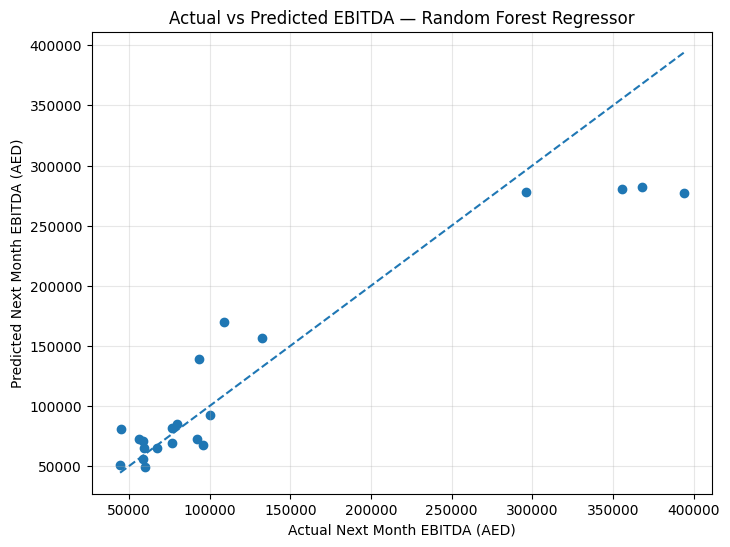

,period,company_id,company_name,actual_next_month_ebitda_aed,predicted_linear_regression,predicted_random_forest,best_model_prediction,absolute_error_best_model
64,2026-02-01,C004,Lapiz Blue Real Estate,355467.0,302375.551475,280329.250123,280329.250123,75137.749877
81,2026-02-01,C005,Lapiz Blue Logistics,56038.0,76431.595111,72415.382394,72415.382394,16377.382394
98,2026-02-01,C006,Lapiz Blue Facilities,67613.0,151738.237258,65032.802291,65032.802291,2580.197709
14,2026-03-01,C001,Lapiz Blue Trading,100177.0,80853.989636,92568.148532,92568.148532,7608.851468
31,2026-03-01,C002,Lapiz Blue Technology,44550.0,54825.115899,50902.150632,50902.150632,6352.150632
48,2026-03-01,C003,Lapiz Blue Hospitality,132617.0,173794.627248,156931.913669,156931.913669,24314.913669
65,2026-03-01,C004,Lapiz Blue Real Estate,368033.0,373659.456485,282469.238512,282469.238512,85563.761488
82,2026-03-01,C005,Lapiz Blue Logistics,92438.0,214938.813070,72779.271705,72779.271705,19658.728295
99,2026-03-01,C006,Lapiz Blue Facilities,76501.0,70490.053002,69458.406323,69458.406323,7042.593677
15,2026-04-01,C001,Lapiz Blue Trading,45281.0,56681.477909,80725.333222,80725.333222,35444.333222


Saved: forecasting_predictions_output.csv


In [9]:
# Choose the better model by lowest RMSE
best_model_name = forecast_results.sort_values('RMSE').iloc[0]['Model']
best_predictions = y_pred_rf if best_model_name == 'Random Forest Regressor' else y_pred_linear

plt.figure(figsize=(8, 6))
plt.scatter(y_test_f, best_predictions)
min_val = min(y_test_f.min(), best_predictions.min())
max_val = max(y_test_f.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel('Actual Next Month EBITDA (AED)')
plt.ylabel('Predicted Next Month EBITDA (AED)')
plt.title(f'Actual vs Predicted EBITDA — {best_model_name}')
plt.grid(True, alpha=0.3)
plt.show()

forecast_predictions = df_sorted.iloc[split_index:].copy()
forecast_predictions['actual_next_month_ebitda_aed'] = y_test_f.values
forecast_predictions['predicted_linear_regression'] = y_pred_linear
forecast_predictions['predicted_random_forest'] = y_pred_rf
forecast_predictions['best_model_prediction'] = best_predictions
forecast_predictions['absolute_error_best_model'] = abs(
    forecast_predictions['actual_next_month_ebitda_aed'] - forecast_predictions['best_model_prediction']
)

display(forecast_predictions[[
    'period', 'company_id', 'company_name',
    'actual_next_month_ebitda_aed',
    'predicted_linear_regression',
    'predicted_random_forest',
    'best_model_prediction',
    'absolute_error_best_model'
]].head(10))

forecast_predictions.to_csv('forecasting_predictions_output.csv', index=False)
print('Saved: forecasting_predictions_output.csv')


## 10. Forecasting feature importance

This helps explain what the Random Forest model used most when predicting next month EBITDA.


,feature,importance
1,budget_revenue_aed,0.116359
5,ebitda_aed,0.116329
4,gross_profit_aed,0.113869
6,budget_ebitda_aed,0.112065
21,profit_margin,0.111174
22,gross_margin,0.108799
23,expense_ratio,0.103456
3,operating_expenses_aed,0.071547
26,cash_flow_net_aed,0.035745
7,cash_in_aed,0.034465


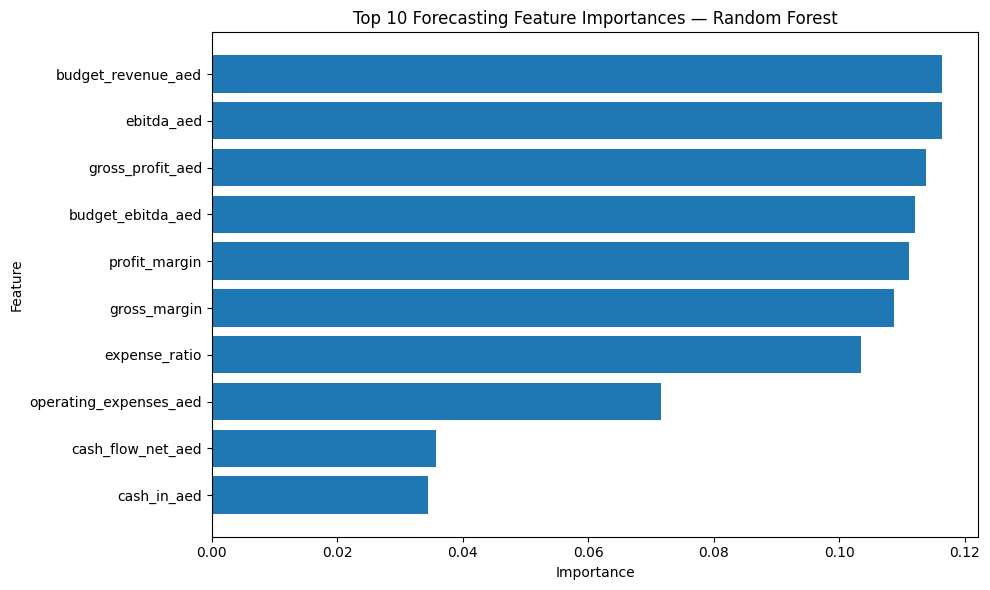

In [10]:
rf_model = rf_regressor.named_steps['model']
feature_importance = pd.DataFrame({
    'feature': feature_cols_forecast,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'][::-1], feature_importance.head(10)['importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Forecasting Feature Importances — Random Forest')
plt.tight_layout()
plt.show()


---
# Part B — Unusual Number / Anomaly Detection

The anomaly task flags unusual financial metric movements such as sudden drops, spikes, or abnormal changes.


## 11. Load anomaly detection dataset

In [11]:
anomaly_path = 'person5_anomaly_detection_dataset.csv'
df_anomaly = pd.read_csv(anomaly_path)

print('Shape:', df_anomaly.shape)
display(df_anomaly.head())


Shape: (216, 18)


,period,organization_id,branch_id,brand_id,salesperson_master_id,metric_name,actual_value,previous_value,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,pct_change,difference_from_rolling_mean_3,z_score_3,z_score_6,rule_based_anomaly,is_anomaly_label
0,45658,719219457,ALL,ALL,ALL,collections_aed,12578.47,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0
1,45689,719219457,ALL,ALL,ALL,collections_aed,35317.42,12578.47,12578.470000,0.000000,12578.470000,0.000000,1.807768,22738.950000,0.000000,0.000000,1,0
2,45717,719219457,ALL,ALL,ALL,collections_aed,23880.89,35317.42,23947.945000,16078.865742,23947.945000,16078.865742,-0.323821,-67.055000,-0.004170,-0.004170,0,0
3,45748,719219457,ALL,ALL,ALL,collections_aed,25724.36,23880.89,23925.593333,11369.540913,23925.593333,11369.540913,0.077194,1798.766667,0.158209,0.158209,0,0
4,45778,719219457,ALL,ALL,ALL,collections_aed,30625.66,25724.36,28307.556667,6140.295870,24375.285000,9326.656998,0.190531,2318.103333,0.377523,0.670162,0,0


## 12. Anomaly data checks

In [12]:
print('Columns:')
print(df_anomaly.columns.tolist())

print('\nMissing values per column:')
missing_anomaly = df_anomaly.isna().sum()
display(missing_anomaly[missing_anomaly > 0].sort_values(ascending=False))

print('\nMetric counts:')
display(df_anomaly['metric_name'].value_counts())

print('\nKnown anomaly label distribution:')
display(df_anomaly['is_anomaly_label'].value_counts())


Columns:
['period', 'organization_id', 'branch_id', 'brand_id', 'salesperson_master_id', 'metric_name', 'actual_value', 'previous_value', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'pct_change', 'difference_from_rolling_mean_3', 'z_score_3', 'z_score_6', 'rule_based_anomaly', 'is_anomaly_label']

Missing values per column:


Series([], dtype: int64)


Metric counts:


metric_name
collections_aed     72
gross_margin_pct    72
sales_aed           72
Name: count, dtype: int64


Known anomaly label distribution:


is_anomaly_label
0    213
1      3
Name: count, dtype: int64

## 13. Prepare anomaly detection features

We use the numerical columns that describe recent movement, rolling averages, z-scores, and rule-based anomaly indicators.


In [13]:
target_anomaly = 'is_anomaly_label'

preferred_anomaly_features = [
    'actual_value',
    'previous_value',
    'rolling_mean_3',
    'rolling_std_3',
    'rolling_mean_6',
    'rolling_std_6',
    'pct_change',
    'difference_from_rolling_mean_3',
    'z_score_3',
    'z_score_6',
    'rule_based_anomaly'
]

feature_cols_anomaly = [col for col in preferred_anomaly_features if col in df_anomaly.columns]

X_anomaly = df_anomaly[feature_cols_anomaly].copy()
y_anomaly = df_anomaly[target_anomaly].copy()

print('Anomaly features:', feature_cols_anomaly)
print('Actual anomaly rate:', y_anomaly.mean())


Anomaly features: ['actual_value', 'previous_value', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'pct_change', 'difference_from_rolling_mean_3', 'z_score_3', 'z_score_6', 'rule_based_anomaly']
Actual anomaly rate: 0.013888888888888888


## 14. Train Isolation Forest model

In [14]:
# Use the known anomaly rate as a guide for contamination, but keep it within a reasonable range.
actual_anomaly_rate = max(y_anomaly.mean(), 1 / len(y_anomaly))
contamination = min(max(actual_anomaly_rate, 0.01), 0.10)

iso_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42
    ))
])

iso_pipeline.fit(X_anomaly)

raw_pred = iso_pipeline.predict(X_anomaly)  # 1 = normal, -1 = anomaly
df_anomaly['isolation_forest_raw_prediction'] = raw_pred
df_anomaly['iforest_anomaly_flag'] = np.where(raw_pred == -1, 1, 0)

df_anomaly['anomaly_score'] = iso_pipeline.named_steps['model'].decision_function(
    iso_pipeline.named_steps['scaler'].transform(
        iso_pipeline.named_steps['imputer'].transform(X_anomaly)
    )
)

print('Isolation Forest trained successfully.')
print('Contamination used:', contamination)
print('\nPredicted anomaly distribution:')
display(df_anomaly['iforest_anomaly_flag'].value_counts())


Isolation Forest trained successfully.
Contamination used: 0.013888888888888888

Predicted anomaly distribution:


iforest_anomaly_flag
0    213
1      3
Name: count, dtype: int64

## 15. Evaluate anomaly detection model

The model is unsupervised, but since this dataset includes `is_anomaly_label`, we compare the model flags against the known labels.


In [15]:
y_pred_anomaly = df_anomaly['iforest_anomaly_flag']

cm = confusion_matrix(y_anomaly, y_pred_anomaly)
print('Confusion Matrix:')
print(cm)

print('\nClassification Report:')
print(classification_report(y_anomaly, y_pred_anomaly, zero_division=0))

precision = precision_score(y_anomaly, y_pred_anomaly, zero_division=0)
recall = recall_score(y_anomaly, y_pred_anomaly, zero_division=0)
f1 = f1_score(y_anomaly, y_pred_anomaly, zero_division=0)

anomaly_results = pd.DataFrame({
    'Model': ['Isolation Forest'],
    'Precision': [precision],
    'Recall': [recall],
    'F1-score': [f1],
    'Known anomalies': [int(y_anomaly.sum())],
    'Predicted anomalies': [int(y_pred_anomaly.sum())]
})

display(anomaly_results)


Confusion Matrix:
[[210   3]
 [  3   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       213
           1       0.00      0.00      0.00         3

    accuracy                           0.97       216
   macro avg       0.49      0.49      0.49       216
weighted avg       0.97      0.97      0.97       216



,Model,Precision,Recall,F1-score,Known anomalies,Predicted anomalies
0,Isolation Forest,0.0,0.0,0.0,3,3


## 16. Create anomaly alerts table with explanations

In [16]:
def explain_anomaly(row):
    metric = row.get('metric_name', 'metric')
    actual = row.get('actual_value', np.nan)
    previous = row.get('previous_value', np.nan)
    rolling_mean = row.get('rolling_mean_3', np.nan)
    pct_change = row.get('pct_change', np.nan)
    z_score = row.get('z_score_3', np.nan)
    rule_flag = row.get('rule_based_anomaly', 0)

    direction = 'higher than usual' if actual > rolling_mean else 'lower than usual'

    reasons = []
    if pd.notna(rolling_mean):
        reasons.append(f'actual value is {direction} compared with the recent 3-period average')
    if pd.notna(pct_change) and abs(pct_change) > 0.25:
        reasons.append(f'percentage change is large ({pct_change:.2%})')
    if pd.notna(z_score) and abs(z_score) >= 2:
        reasons.append(f'z-score is high ({z_score:.2f})')
    if rule_flag == 1:
        reasons.append('the rule-based check also flagged this row')

    if not reasons:
        reasons.append('the Isolation Forest model found this row unusual compared with the rest of the data')

    return f'{metric} was flagged because ' + '; '.join(reasons) + '.'

alerts = df_anomaly[df_anomaly['iforest_anomaly_flag'] == 1].copy()
alerts['explanation'] = alerts.apply(explain_anomaly, axis=1)

alert_cols = [
    'period', 'organization_id', 'branch_id', 'brand_id', 'salesperson_master_id',
    'metric_name', 'actual_value', 'previous_value', 'rolling_mean_3',
    'pct_change', 'z_score_3', 'rule_based_anomaly', 'is_anomaly_label',
    'iforest_anomaly_flag', 'anomaly_score', 'explanation'
]
alert_cols = [col for col in alert_cols if col in alerts.columns]

alerts_output = alerts[alert_cols].sort_values('anomaly_score')
display(alerts_output)

alerts_output.to_csv('anomaly_alerts_output.csv', index=False)
df_anomaly.to_csv('anomaly_detection_full_output.csv', index=False)
print('Saved: anomaly_alerts_output.csv')
print('Saved: anomaly_detection_full_output.csv')


,period,organization_id,branch_id,brand_id,salesperson_master_id,metric_name,actual_value,previous_value,rolling_mean_3,pct_change,z_score_3,rule_based_anomaly,is_anomaly_label,iforest_anomaly_flag,anomaly_score,explanation
209,45992,903438347,ALL,ALL,ALL,sales_aed,1064703.81,350551.59,721736.153333,2.037224,0.979857,1,0,1,-0.007765,sales_aed was flagged because actual value is ...
204,45839,903438347,ALL,ALL,ALL,sales_aed,1022391.62,878099.43,564371.010000,0.164323,1.651650,0,0,1,-0.005327,sales_aed was flagged because actual value is ...
210,46023,903438347,ALL,ALL,ALL,sales_aed,378008.29,1064703.81,820357.643333,-0.644964,-1.086924,1,0,1,-0.004555,sales_aed was flagged because actual value is ...


Saved: anomaly_alerts_output.csv
Saved: anomaly_detection_full_output.csv


## 17. Final model summary

In [17]:
print('FORECASTING SUMMARY')
display(forecast_results)
print('Best forecasting model by RMSE:', best_model_name)

print('\nANOMALY DETECTION SUMMARY')
display(anomaly_results)
print('Number of generated alert rows:', len(alerts_output))


FORECASTING SUMMARY


,Model,MAE,RMSE,R2
0,Linear Regression,35459.975102,47030.180418,0.822724
1,Random Forest Regressor,28223.596082,41709.727987,0.860565


Best forecasting model by RMSE: Random Forest Regressor

ANOMALY DETECTION SUMMARY


,Model,Precision,Recall,F1-score,Known anomalies,Predicted anomalies
0,Isolation Forest,0.0,0.0,0.0,3,3


Number of generated alert rows: 3


# Final conclusion

The forecasting model predicts `next_month_ebitda_aed`, which makes it a **regression** task. Two models were tested: Linear Regression and Random Forest Regressor. The models were evaluated using MAE, RMSE, and R², and an Actual vs Predicted EBITDA chart was created to visually compare predictions against real values.

The anomaly detection model uses Isolation Forest to flag unusual financial metric movements. The model uses rolling averages, percentage change, z-scores, and rule-based anomaly indicators as inputs. The output is an alerts table that can be connected to the dashboard Alerts tab, showing unusual financial movements in plain English.

**Important note:** The anomaly dataset is highly imbalanced because only a small number of rows are labelled as real anomalies. Because of this, precision, recall, F1-score, and the confusion matrix are more useful than accuracy alone.
